# 06 · Loss Functions: which one, why, and their limits
NumPy for the model · matplotlib for graphs · Runs on Google Colab

1. What a loss does
2. Regression losses: MSE, MAE, Huber, Log-cosh, Quantile
3. Binary classification: BCE, MSE + sigmoid, Hinge, Focal
4. Multiclass: categorical & sparse cross-entropy, label smoothing, KL divergence
5. Text / NLP: next-token cross-entropy & perplexity, triplet loss for embeddings
6. Real use case: predicting a car's fuel efficiency (regression)
7. Summary: which loss for which problem, and its limitation

In [1]:
import io, urllib.request
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def softmax(s):
    e = np.exp(s - s.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def nudge_slope(f, x, h=1e-5):
    # slope by nudging the input a little (same check we have used since the delta-rule notebook)
    return (f(x + h) - f(x - h)) / (2 * h)

---
# Part 1: what a loss does
A loss turns "how wrong" into one number. **Its slope is what drives learning**: different loss ➜ different slope ➜ the network learns differently.
For every loss below: formula, values, slope (checked by nudging), a demo, and its **limitation**.

---
# Part 2: regression losses (predicting a number)
Error $e = \hat{y} - y$.

| Loss | $L(e)$ | Slope $dL/de$ |
|---|---|---|
| MSE | $e^2$ | $2e$ |
| MAE | $\lvert e \rvert$ | $\text{sign}(e)$ |
| Huber ($\delta = 1$) | $\tfrac12 e^2$ if $\lvert e \rvert \le 1$, else $\lvert e \rvert - \tfrac12$ | $e$ clipped to $[-1, 1]$ |
| Log-cosh | $\log(\cosh e)$ | $\tanh(e)$ |

   error e |   -5.0 |   -1.0 |   -0.3 |    0.3 |    1.0 |    5.0
       MSE |  25.00 |   1.00 |   0.09 |   0.09 |   1.00 |  25.00   slope: -10.00 -2.00 -0.60 +0.60 +2.00 +10.00
       MAE |   5.00 |   1.00 |   0.30 |   0.30 |   1.00 |   5.00   slope: -1.00 -1.00 -1.00 +1.00 +1.00 +1.00
     Huber |   4.50 |   0.50 |   0.04 |   0.04 |   0.50 |   4.50   slope: -1.00 -1.00 -0.30 +0.30 +1.00 +1.00
  Log-cosh |   4.31 |   0.43 |   0.04 |   0.04 |   0.43 |   4.31   slope: -1.00 -0.76 -0.29 +0.29 +0.76 +1.00

Nudge check of each slope at e = 2.5:
       MSE: formula +5.0000 | nudging +5.0000
       MAE: formula +1.0000 | nudging +1.0000
     Huber: formula +1.0000 | nudging +1.0000
  Log-cosh: formula +0.9866 | nudging +0.9866


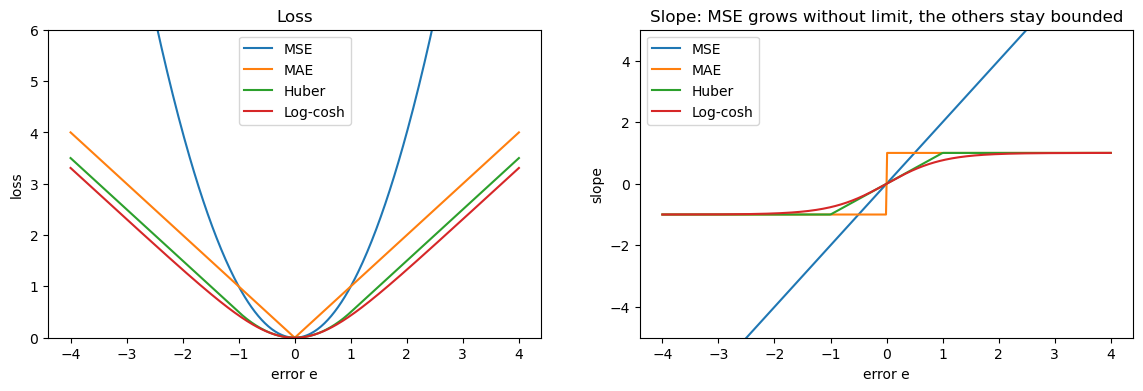

In [2]:
REG = {
    "MSE":      (lambda e: e ** 2,                                         lambda e: 2 * e),
    "MAE":      (lambda e: np.abs(e),                                      lambda e: np.sign(e)),
    "Huber":    (lambda e: np.where(np.abs(e) <= 1, 0.5 * e ** 2, np.abs(e) - 0.5), lambda e: np.clip(e, -1, 1)),
    "Log-cosh": (lambda e: np.log(np.cosh(e)),                             lambda e: np.tanh(e)),
}

errors = np.array([-5.0, -1.0, -0.3, 0.3, 1.0, 5.0])
print(f"{'error e':>10} | " + " | ".join(f"{e:6.1f}" for e in errors))
for name, (f, df) in REG.items():
    print(f"{name:>10} | " + " | ".join(f"{v:6.2f}" for v in f(errors)) + "   slope: " + " ".join(f"{v:+.2f}" for v in df(errors)))

print("\nNudge check of each slope at e = 2.5:")
for name, (f, df) in REG.items():
    print(f"  {name:>8}: formula {float(df(np.array(2.5))):+.4f} | nudging {float(nudge_slope(f, np.array(2.5))):+.4f}")

es = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, (f, df) in REG.items():
    axes[0].plot(es, f(es), label=name)
    axes[1].plot(es, df(es), label=name)
axes[0].set(xlabel="error e", ylabel="loss", ylim=(0, 6), title="Loss")
axes[1].set(xlabel="error e", ylabel="slope", ylim=(-5, 5), title="Slope: MSE grows without limit, the others stay bounded")
axes[0].legend()
axes[1].legend()
plt.show()

## Demo: fit a line to data with 5 outliers (true line $y = 2x + 1$)

     MSE: w = 1.64, b = 6.74   (true: w = 2, b = 1)
     MAE: w = 1.91, b = 1.52   (true: w = 2, b = 1)
   Huber: w = 1.97, b = 1.23   (true: w = 2, b = 1)
Log-cosh: w = 1.97, b = 1.27   (true: w = 2, b = 1)


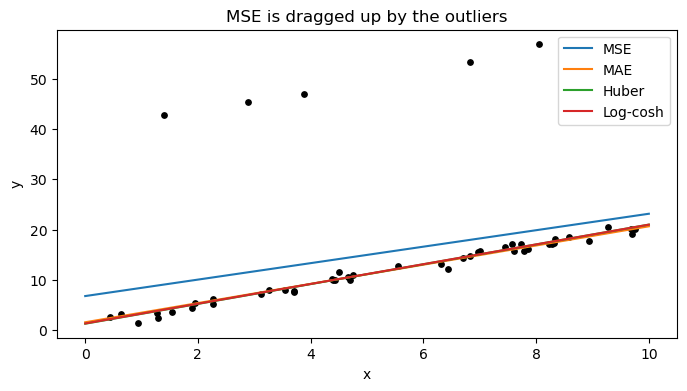

In [3]:
x_line = rng.uniform(0, 10, 50)
y_line = 2 * x_line + 1 + rng.normal(0, 1, 50)
y_line[-5:] += 40                                                 # 5 outliers

def fit_line(slope_fn, lr, steps=5000):
    w = b = 0.0
    for _ in range(steps):
        g = slope_fn(w * x_line + b - y_line)                     # slope of the loss for every point
        w -= lr * np.mean(g * x_line)
        b -= lr * np.mean(g)
    return w, b

xs = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_line, y_line, c="k", s=15)
for name, (_, df) in REG.items():
    w, b = fit_line(df, 0.002 if name == "MSE" else 0.05)
    print(f"{name:>8}: w = {w:.2f}, b = {b:.2f}   (true: w = 2, b = 1)")
    ax.plot(xs, w * xs + b, label=name)
ax.set(xlabel="x", ylabel="y", title="MSE is dragged up by the outliers")
ax.legend()
plt.show()

## Quantile (pinball) loss: predict a range, not just the middle
$L = q \cdot e$ if the true value is above the prediction, else $(1-q) \cdot (-e)$ (here $e = y - \hat{y}$). Quantile $q = 0.9$ ➜ a line that 90% of the points fall below.

q = 0.1: line y = 0.58x + -0.34 | share of points below it = 0.10
q = 0.5: line y = 0.98x + -0.03 | share of points below it = 0.50
q = 0.9: line y = 1.45x + 0.02 | share of points below it = 0.90


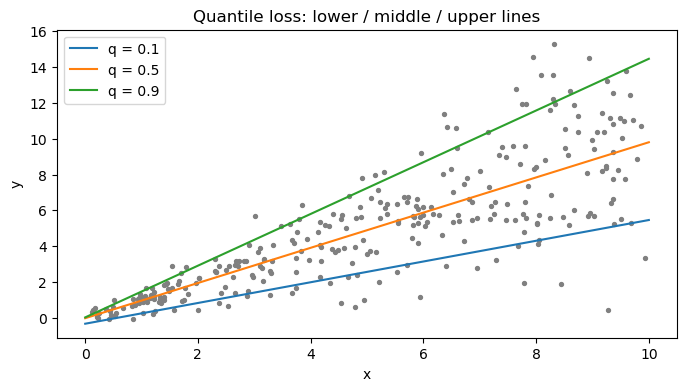

In [4]:
x_q = rng.uniform(0, 10, 300)
y_q = x_q + rng.normal(0, 0.2 + 0.3 * x_q, 300)                   # spread grows with x

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_q, y_q, s=8, c="gray")
for q in [0.1, 0.5, 0.9]:
    w = b = 0.0
    for _ in range(20000):
        e = y_q - (w * x_q + b)
        g = np.where(e > 0, -q, 1 - q)                            # slope of the pinball loss
        w -= 0.01 * np.mean(g * x_q)
        b -= 0.01 * np.mean(g)
    print(f"q = {q}: line y = {w:.2f}x + {b:.2f} | share of points below it = {np.mean(y_q < w * x_q + b):.2f}")
    ax.plot(xs, w * xs + b, label=f"q = {q}")
ax.set(xlabel="x", ylabel="y", title="Quantile loss: lower / middle / upper lines")
ax.legend()
plt.show()

| Loss | Good for | Limitation |
|---|---|---|
| MSE | most regression; smooth slope | outliers dominate (errors are squared) |
| MAE | data with outliers | slope is always ±1: no slowing down near the answer, and no slope at exactly 0 |
| Huber | outliers + smooth near 0 | one extra setting ($\delta$) to choose |
| Log-cosh | like Huber, no setting | for big errors behaves like MAE, so outliers still pull a little |
| Quantile | ranges / uncertainty | one model per quantile; slope ±q only |

---
# Part 3: binary classification (yes / no)
Score $s$, probability $p = \text{sigmoid}(s)$, target $y \in \{0, 1\}$.

| Loss | $L$ | Slope $dL/ds$ |
|---|---|---|
| Binary cross-entropy (BCE) | $-[y \log p + (1-y)\log(1-p)]$ | $p - y$ |
| MSE + sigmoid | $(p - y)^2$ | $2(p - y)\,p(1-p)$ |
| Hinge (labels $\pm 1$) | $\max(0,\; 1 - y\,s)$ | $-y$ if $y s < 1$, else 0 |
| Focal ($\gamma = 2$) | $-(1-p_t)^\gamma \log p_t$, $p_t$ = probability of the correct class | down-weights easy examples |

In [5]:
def bce(y, p):
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

y_true = 1.0
print("Confidently WRONG: target 1, output p = sigmoid(s) small")
for s in [-6.0, -3.0, 0.0, 3.0]:
    p = sigmoid(s)
    print(f"  s = {s:+.0f}, p = {p:.4f} | BCE {bce(y_true, p):6.3f}, slope {p - y_true:+.4f} | "
          f"MSE {(p - y_true) ** 2:.3f}, slope {2 * (p - y_true) * p * (1 - p):+.4f}")
print(f"\nNudge check at s = -3: BCE slope {nudge_slope(lambda s: bce(1.0, sigmoid(s)), -3.0):+.4f}, "
      f"MSE slope {nudge_slope(lambda s: (sigmoid(s) - 1) ** 2, -3.0):+.4f}")

Confidently WRONG: target 1, output p = sigmoid(s) small
  s = -6, p = 0.0025 | BCE  6.002, slope -0.9975 | MSE 0.995, slope -0.0049
  s = -3, p = 0.0474 | BCE  3.049, slope -0.9526 | MSE 0.907, slope -0.0861
  s = +0, p = 0.5000 | BCE  0.693, slope -0.5000 | MSE 0.250, slope -0.2500
  s = +3, p = 0.9526 | BCE  0.049, slope -0.0474 | MSE 0.002, slope -0.0043

Nudge check at s = -3: BCE slope -0.9526, MSE slope -0.0861


When the network is confidently wrong (p ≈ 0), BCE's slope is about −1 (strong push); MSE's is almost 0 because it is multiplied by $p(1-p)$. **MSE + sigmoid learns very slowly from big mistakes.**

## Demo: same neuron, same confidently-wrong start, BCE vs MSE

BCE: first epoch with 95% accuracy = 106
MSE: first epoch with 95% accuracy = not within 200


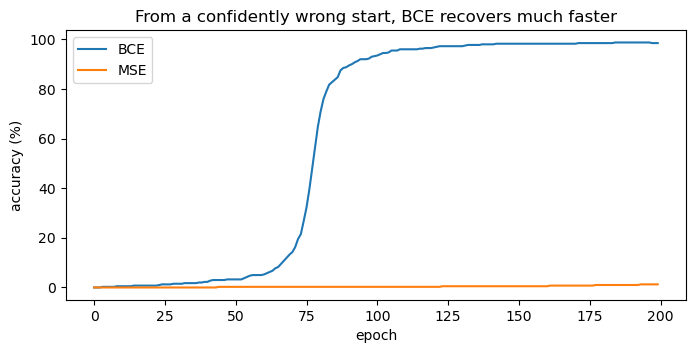

In [6]:
X_b = rng.normal(0, 1, (400, 2))
y_b = (X_b[:, 0] + X_b[:, 1] > 0).astype(float)

fig, ax = plt.subplots(figsize=(8, 3.5))
for name in ["BCE", "MSE"]:
    w, b, accs = np.array([-4.0, -4.0]), 0.0, []                  # start pointing the wrong way
    for _ in range(200):
        p = sigmoid(X_b @ w + b)
        g = (p - y_b) if name == "BCE" else 2 * (p - y_b) * p * (1 - p)
        w, b = w - 0.1 * X_b.T @ g / len(X_b), b - 0.1 * g.mean()
        accs.append(100 * ((sigmoid(X_b @ w + b) > 0.5) == y_b).mean())
    first = next((i + 1 for i, a in enumerate(accs) if a >= 95), None)
    print(f"{name}: first epoch with 95% accuracy = {first if first else 'not within 200'}")
    ax.plot(accs, label=name)
ax.set(xlabel="epoch", ylabel="accuracy (%)", title="From a confidently wrong start, BCE recovers much faster")
ax.legend()
plt.show()

## Hinge vs BCE: hinge is satisfied at margin 1, BCE keeps pushing

In [7]:
X_h = np.vstack([rng.normal(-2, 0.7, (50, 2)), rng.normal(2, 0.7, (50, 2))])
y_h = np.r_[-np.ones(50), np.ones(50)]                            # hinge uses labels -1 / +1

for name in ["hinge", "BCE"]:
    w, b = np.zeros(2), 0.0
    for _ in range(2000):
        margin = y_h * (X_h @ w + b)
        g = np.where(margin < 1, -y_h, 0.0) if name == "hinge" else -y_h * sigmoid(-margin)
        w, b = w - 0.05 * X_h.T @ g / len(X_h), b - 0.05 * g.mean()
    margin = y_h * (X_h @ w + b)
    print(f"{name:>5}: smallest margin {margin.min():.2f} | size of w {np.linalg.norm(w):.2f} | loss at the end "
          f"{np.mean(np.maximum(0, 1 - margin)) if name == 'hinge' else np.mean(np.log(1 + np.exp(-margin))):.4f}")

hinge: smallest margin 1.00 | size of w 0.63 | loss at the end 0.0000
  BCE: smallest margin 3.72 | size of w 2.48 | loss at the end 0.0020


Hinge loss reaches exactly 0 once every point is at least 1 away from the line, then stops. BCE never reaches 0, so it keeps growing the weights (more and more confident).

## Focal loss: focus on the hard examples

In [8]:
print(f"{'p of the correct class':>22} | {'BCE':>6} | {'focal (γ=2)':>11} | focal / BCE")
for pt in [0.95, 0.8, 0.5, 0.2, 0.05]:
    b_loss, f_loss = -np.log(pt), -(1 - pt) ** 2 * np.log(pt)
    print(f"{pt:>22} | {b_loss:6.3f} | {f_loss:11.4f} | {f_loss / b_loss:.3f}")

p of the correct class |    BCE | focal (γ=2) | focal / BCE
                  0.95 |  0.051 |      0.0001 | 0.003
                   0.8 |  0.223 |      0.0089 | 0.040
                   0.5 |  0.693 |      0.1733 | 0.250
                   0.2 |  1.609 |      1.0300 | 0.640
                  0.05 |  2.996 |      2.7036 | 0.902


Easy examples (p = 0.95) count 400× less than with BCE, so training focuses on the hard ones. This helps when easy examples vastly outnumber hard ones (e.g. object detection). On small, simple data it often changes nothing.

| Loss | Good for | Limitation |
|---|---|---|
| BCE | yes/no with a sigmoid output | never reaches 0 ➜ can become over-confident; sensitive to wrong labels |
| MSE + sigmoid | (historical) | tiny slope when confidently wrong ➜ very slow learning |
| Hinge | margin classifiers (SVM-style) | no probabilities, only a score; slope 0 once the margin is met |
| Focal | heavy imbalance, many easy examples | extra setting γ; little gain on simple data |

---
# Part 4: multiclass
## Categorical vs sparse cross-entropy: the same loss, two label formats

In [9]:
scores = np.array([2.0, 1.0, 0.1])
p = softmax(scores)
one_hot, index = np.array([0, 1, 0]), 1
print("probabilities      :", p)
print(f"categorical CE (one-hot [0,1,0]): -Σ y·log p = {-np.sum(one_hot * np.log(p)):.4f}")
print(f"sparse CE (label index 1)       : -log p[1]  = {-np.log(p[index]):.4f}   (same number, no one-hot needed)")

probabilities      : [0.659  0.2424 0.0986]
categorical CE (one-hot [0,1,0]): -Σ y·log p = 1.4170
sparse CE (label index 1)       : -log p[1]  = 1.4170   (same number, no one-hot needed)


Sparse cross-entropy is used when there are many classes, e.g. a vocabulary of 50,000 words: storing one index is much cheaper than a one-hot vector.

## Label smoothing: don't aim for 100% certainty
Target `[0, 1, 0]` becomes `[ε/K, 1-ε+ε/K, ε/K]`. With ε = 0.1, K = 3: `[0.033, 0.933, 0.033]`.

In [10]:
def smooth(one_hot, eps):
    return one_hot * (1 - eps) + eps / len(one_hot)

for eps in [0.0, 0.1]:
    t = smooth(one_hot.astype(float), eps)
    note = "needs scores of ±infinity to reach exactly 0 and 1 ➜ the network keeps pushing" if eps == 0 else \
           f"reachable with finite scores, e.g. {np.round(np.log(t), 2)}"
    print(f"ε = {eps}: best possible output = target {np.round(t, 3)} -> {note}")

ε = 0.0: best possible output = target [0. 1. 0.] -> needs scores of ±infinity to reach exactly 0 and 1 ➜ the network keeps pushing
ε = 0.1: best possible output = target [0.033 0.933 0.033] -> reachable with finite scores, e.g. [-3.4  -0.07 -3.4 ]


## KL divergence: how different are two probability distributions?
$\text{KL}(p\,\|\,q) = \sum p \log\frac{p}{q}$, and cross-entropy $=$ entropy of $p$ $+$ KL. Used when the target is itself a distribution (teacher ➜ student "distillation", and autoencoders later).

In [11]:
p_true = np.array([0.7, 0.2, 0.1])
for q in [np.array([0.7, 0.2, 0.1]), np.array([0.5, 0.3, 0.2]), np.array([0.1, 0.2, 0.7])]:
    entropy = -np.sum(p_true * np.log(p_true))
    kl = np.sum(p_true * np.log(p_true / q))
    ce = -np.sum(p_true * np.log(q))
    print(f"q = {q}: KL = {kl:.4f} | entropy + KL = {entropy:.4f} + {kl:.4f} = {entropy + kl:.4f} | cross-entropy = {ce:.4f}")

q = [0.7 0.2 0.1]: KL = 0.0000 | entropy + KL = 0.8018 + 0.0000 = 0.8018 | cross-entropy = 0.8018
q = [0.5 0.3 0.2]: KL = 0.0851 | entropy + KL = 0.8018 + 0.0851 = 0.8869 | cross-entropy = 0.8869
q = [0.1 0.2 0.7]: KL = 1.1675 | entropy + KL = 0.8018 + 1.1675 = 1.9694 | cross-entropy = 1.9694


| Loss | Good for | Limitation |
|---|---|---|
| Categorical CE | one of K classes, one-hot labels | over-confident; wrong labels hurt |
| Sparse CE | same, labels as indices (big vocabularies) | same as categorical CE |
| Label smoothing | reduces over-confidence | slightly lower confidence on correct answers; one setting ε |
| KL divergence | matching a whole distribution | not symmetric: KL(p‖q) ≠ KL(q‖p); infinite if q = 0 where p > 0 |

---
# Part 5: text / NLP
## Next-character prediction with cross-entropy, and perplexity
A tiny language model: predict the next character from the current one (one softmax over the vocabulary).
**Perplexity** $= e^{\text{cross-entropy}}$ ≈ "how many characters the model is choosing between". Random guessing = vocabulary size.

In [12]:
text = "the cat sat on the mat. the dog sat on the log. the cat and the dog are friends. " * 20
chars = sorted(set(text))
V = len(chars)
to_id = {c: i for i, c in enumerate(chars)}
cur = np.array([to_id[c] for c in text[:-1]])
nxt = np.array([to_id[c] for c in text[1:]])
print(f"vocabulary: {V} characters {chars}")

def perplexity(W):
    P = softmax(W[cur])
    return np.exp(-np.mean(np.log(P[np.arange(len(cur)), nxt])))

def train_char_model(eps, epochs=200):
    W = np.zeros((V, V))                                          # row = current char, column = score of each next char
    target = smooth(np.eye(V)[nxt], eps)
    for _ in range(epochs):
        G = np.zeros_like(W)
        np.add.at(G, cur, softmax(W[cur]) - target)                # slope of cross-entropy: p - y
        W -= V * G / len(cur)
    return W

W_char = train_char_model(0.0)
print(f"perplexity before training: {perplexity(np.zeros((V, V))):.2f} (= vocabulary size) | after: {perplexity(W_char):.2f}")

def generate(W, start="t", n=60):
    out = start
    for _ in range(n):
        out += chars[rng.choice(V, p=softmax(W[to_id[out[-1]]]))]
    return out
print("generated:", generate(W_char))

vocabulary: 17 characters [' ', '.', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'r', 's', 't']
perplexity before training: 17.00 (= vocabulary size) | after: 2.47
generated: the t t the on d the og s. t og. t can at cathendon fre d dsa


In [13]:
W_smooth = train_char_model(0.1)
for name, W in [("no smoothing", W_char), ("label smoothing ε = 0.1", W_smooth)]:
    print(f"{name:>24}: perplexity {perplexity(W):.2f} | average highest probability {softmax(W[cur]).max(axis=1).mean():.3f}")

            no smoothing: perplexity 2.47 | average highest probability 0.625
 label smoothing ε = 0.1: perplexity 2.65 | average highest probability 0.572


Label smoothing keeps the model a little less certain (lower top probability), which usually generalises better on real text.

## Triplet loss: learning embeddings (vectors for words or sentences)
$L = \max(0,\; d(a, p) - d(a, n) + \text{margin})$: the **anchor** should be closer to the **positive** (similar) than to the **negative** (different) by at least a margin.

loss before: 4.415
loss after : 0.000


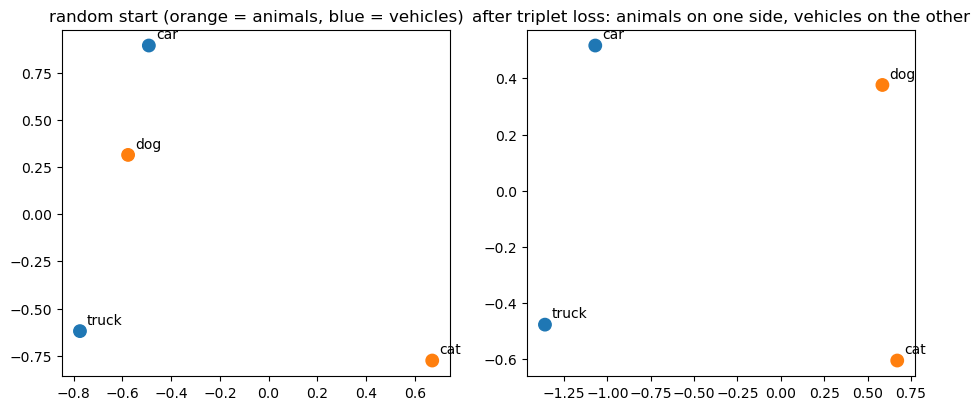

In [14]:
words = ["cat", "dog", "car", "truck"]
E = rng.normal(0, 1, (4, 2))                                      # a random 2-D vector for each word
triplets = [(0, 1, 2), (1, 0, 3), (2, 3, 0), (3, 2, 1)]           # (anchor, similar, different)
E_start = E.copy()

def triplet_loss(E, margin=1.0):
    return sum(max(0, np.linalg.norm(E[a] - E[p]) - np.linalg.norm(E[a] - E[n]) + margin) for a, p, n in triplets)

print(f"loss before: {triplet_loss(E):.3f}")
for _ in range(300):
    G = np.zeros_like(E)
    for a, p, n in triplets:
        dap, dan = E[a] - E[p], E[a] - E[n]
        if np.linalg.norm(dap) - np.linalg.norm(dan) + 1.0 > 0:   # only violated triplets push
            ga, gp = dap / (np.linalg.norm(dap) + 1e-9), dan / (np.linalg.norm(dan) + 1e-9)
            G[a] += ga - gp
            G[p] -= ga
            G[n] += gp
    E -= 0.05 * G
print(f"loss after : {triplet_loss(E):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, emb, title in [(axes[0], E_start, "random start (orange = animals, blue = vehicles)"),
                       (axes[1], E, "after triplet loss: animals on one side, vehicles on the other")]:
    ax.scatter(emb[:, 0], emb[:, 1], c=["tab:orange", "tab:orange", "tab:blue", "tab:blue"], s=80)
    for w, (u, v) in zip(words, emb):
        ax.annotate(w, (u, v), xytext=(5, 5), textcoords="offset points")
    ax.set(title=title)
plt.show()

| Loss | Good for | Limitation |
|---|---|---|
| CE over the vocabulary | language models (next token) | the softmax over a huge vocabulary is expensive |
| Perplexity | measuring a language model | a metric, not trained directly; only comparable with the same vocabulary |
| Triplet / contrastive | embeddings, similarity search | needs good "hard" negatives; most triplets quickly give 0 loss |

---
# Part 6: real use case — predicting a car's fuel efficiency (miles per gallon)
Network: 6 inputs ➜ 32 ReLU ➜ **1 linear output** (no activation, any number allowed). Trained with MSE, MAE or Huber, on clean targets and with 10% of the training targets corrupted (×3).

In [15]:
raw = urllib.request.urlopen("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv").read().decode()
data = np.genfromtxt(io.StringIO(raw), delimiter=",", skip_header=1, usecols=(0, 1, 2, 3, 4, 5, 6))
data = data[~np.isnan(data).any(axis=1)]                           # drop cars with missing values
y_mpg, X_mpg = data[:, 0], data[:, 1:]
print(f"{len(data)} cars | inputs: cylinders, displacement, horsepower, weight, acceleration, model year | target: mpg")

order = rng.permutation(len(data))
te, tr = order[:80], order[80:]
mean, std = X_mpg[tr].mean(axis=0), X_mpg[tr].std(axis=0)
X0 = np.hstack([-np.ones((len(data), 1)), (X_mpg - mean) / std])   # x0 = -1 for the thresholds

392 cars | inputs: cylinders, displacement, horsepower, weight, acceleration, model year | target: mpg


In [16]:
def forward_pass(x, W1, W2):
    s1 = x @ W1
    h = np.r_[-1, np.maximum(0, s1)]
    return h @ W2, (s1, h)                                        # linear output: the prediction itself

def compute_error(y, y_hat):
    return y_hat - y

def backward_pass(W1, W2, x, slope, cache, lr):
    s1, h = cache
    delta_hidden = W2[1:] * slope * (s1 > 0)
    return W1 - lr * np.outer(x, delta_hidden), W2 - lr * slope * h

def train(y_train, loss_name, epochs=200):
    W1, W2 = rng.normal(0, np.sqrt(2 / 6), (7, 32)), rng.normal(0, np.sqrt(2 / 32), 33)
    slope_of, lr = REG[loss_name][1], (0.001 if loss_name == "MSE" else 0.01)
    for _ in range(epochs):
        for i in rng.permutation(len(tr)):
            y_hat, cache = forward_pass(X0[tr[i]], W1, W2)
            W1, W2 = backward_pass(W1, W2, X0[tr[i]], slope_of(compute_error(y_train[i], y_hat)), cache, lr)
    return W1, W2

def predict(W1, W2, idx):
    return np.hstack([-np.ones((len(idx), 1)), np.maximum(0, X0[idx] @ W1)]) @ W2

y_corrupt = y_mpg[tr].copy()
bad = rng.random(len(tr)) < 0.1
y_corrupt[bad] *= 3
print(f"Corrupted training targets: {bad.sum()} of {len(tr)}\n")

print(f"{'loss':>6} | {'test error, clean training (mpg)':>32} | {'test error, 10% corrupted (mpg)':>31}")
print("-" * 76)
models = {}
for name in ["MSE", "MAE", "Huber"]:
    errs = []
    for y_train in [y_mpg[tr], y_corrupt]:
        W1, W2 = train(y_train, name)
        errs.append(np.mean(np.abs(predict(W1, W2, te) - y_mpg[te])))
        models[(name, len(errs))] = (W1, W2)
    print(f"{name:>6} | {errs[0]:32.2f} | {errs[1]:31.2f}")

Corrupted training targets: 37 of 312

  loss | test error, clean training (mpg) | test error, 10% corrupted (mpg)
----------------------------------------------------------------------------
   MSE |                             1.90 |                            7.73
   MAE |                             2.16 |                            3.07
 Huber |                             2.00 |                            2.19


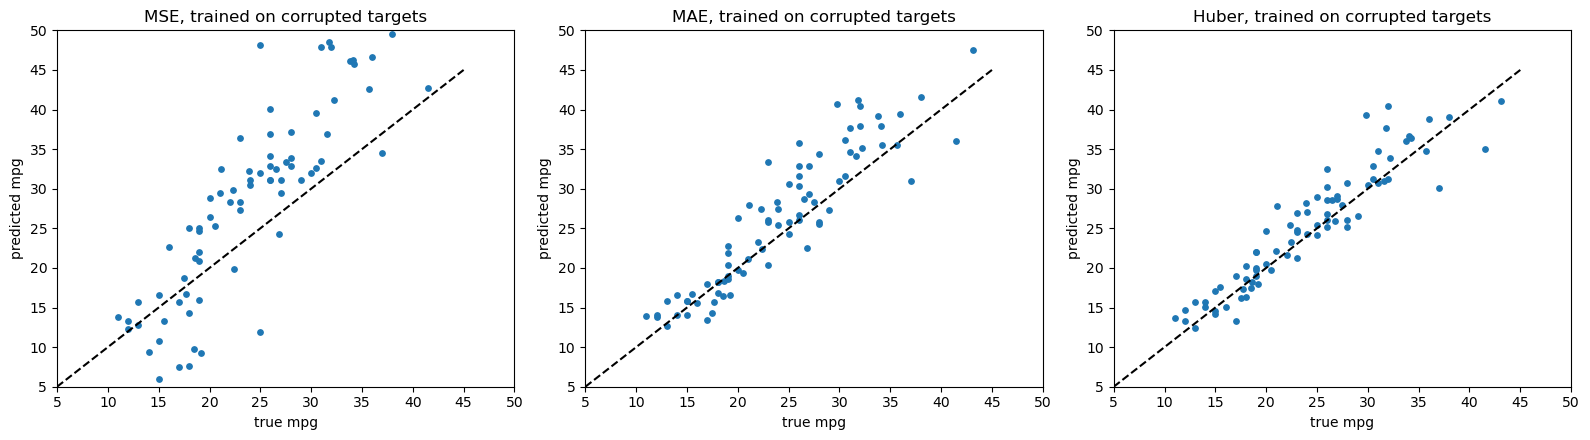

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, ["MSE", "MAE", "Huber"]):
    pred = predict(*models[(name, 2)], te)
    ax.scatter(y_mpg[te], pred, s=15)
    ax.plot([5, 45], [5, 45], "k--")
    ax.set(xlabel="true mpg", ylabel="predicted mpg", title=f"{name}, trained on corrupted targets", xlim=(5, 50), ylim=(5, 50))
plt.tight_layout()
plt.show()

With clean targets the three losses are close. With some wrong targets, MSE is pulled towards them (squared errors), while MAE and Huber barely change.

---
# Part 7: summary — which loss for which problem

| Problem | Output layer | Loss | Main limitation |
|---|---|---|---|
| Predict a number | linear | **MSE** | outliers dominate |
| Number, data with outliers | linear | **Huber** / MAE / Log-cosh | Huber needs δ; MAE has a constant slope |
| A range (e.g. 10%–90%) | linear | **Quantile** | one output per quantile |
| Yes / no | sigmoid | **Binary cross-entropy** | over-confident, hurt by wrong labels |
| Yes / no, rare positives | sigmoid | **Focal** | extra setting γ, small gain on simple data |
| Margin classifier | raw score | **Hinge** | no probabilities |
| One of K classes | softmax | **Categorical / sparse CE** (+ label smoothing) | over-confident without smoothing |
| Match a distribution | softmax | **KL divergence** | not symmetric |
| Next word / token | softmax over vocabulary | **Cross-entropy**, report **perplexity** | expensive for huge vocabularies |
| Similar vs different items | embedding vector | **Triplet / contrastive** | needs good negative examples |